In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Figure 6.4-4 &mdash; oxygen $P$&ndash;$\underline{H}$ diagram (thermo-package version)

Package version of the Figure 6.4-4 notebook: the Peng&ndash;Robinson EOS, its
enthalpy departure (`pr.departure_H`), and the fugacity/saturation solve come
from the shared `thermo` package instead of being coded inline. Compare with the
self-contained `PR_enthalpy_O2_example.ipynb`.

The ideal-gas enthalpy uses the $C_P$ coefficients carried on the `PengRobinson`
object (`pr.cp`); the reference state is the ideal gas at $25\,^{\circ}$C, 1 bar.
Note the `cp=` argument: `from_database` would otherwise return the
Reid&ndash;Prausnitz&ndash;Poling coefficients in `pure_property.csv`, and it is the
book's **Appendix A.II** set that reproduces the printed table. Numbers differ slightly from the self-contained
notebook because `from_database` uses $\omega = 0.025$ ($\kappa = 0.413$) vs. the
book's $\kappa = 0.4069$.

Eric Furst

In [2]:
import sys
sys.path.append("..")           # so `import thermo` finds code/thermo

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Typography, matching the recomputed figures in ch7 (Figs. 7.3-1 to 7.3-4, 7.5-2,
# 7.5-3): use a real LaTeX installation when there is one, so the figure is set in
# Computer Modern like the book, and fall back to matplotlib's own mathtext otherwise —
# the notebook still runs in Colab, which has no TeX.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})
import pandas as pd
from scipy.optimize import brentq

from thermo import PengRobinson, APPENDIX_A2_CP
from thermo.peng_robinson import R

pr = PengRobinson.from_database("oxygen", cp=APPENDIX_A2_CP["oxygen"])
cA, cB, cC, cD = pr.cp          # ideal-gas Cp = cA + cB*T + cC*T^2 + cD*T^3
T_REF, P_REF = 298.15, 1e5      # ideal gas at 25 C, 1 bar -> H = 0
TO_KELVIN, BAR, KJ = 273.15, 1e5, 1e3


def H_ideal(T):
    return (cA * (T - T_REF) + cB / 2 * (T**2 - T_REF**2)
            + cC / 3 * (T**3 - T_REF**3) + cD / 4 * (T**4 - T_REF**4))


def enthalpy(P, T, phase):
    """Molar enthalpy (J/mol) rel. to the ideal gas at 25 C, 1 bar."""
    return H_ideal(T) + pr.departure_H(T, P, phase)


print(f"{pr.name}: Tc = {pr.Tc} K, Pc = {pr.Pc/1e5:.2f} bar, kappa = {pr.kappa:.4f}")
print(f"H(25 C, 1 bar) = {enthalpy(P_REF, T_REF, 'vapor'):.2f} J/mol  (book: -9.44)")


oxygen: Tc = 154.6 K, Pc = 50.40 bar, kappa = 0.4130
H(25 C, 1 bar) = -9.44 J/mol  (book: -9.44)


## Saturation pressure and the two-phase envelope

Bracket the equal-fugacity condition between the isotherm's spinodal pressures
and solve by bisection, using the package building blocks `pr.pressure` and
`pr.ln_phi`. The grid is clustered toward $T_c$ and closed at the critical
point.

In [3]:
def loop_pressure_bounds(T, n=4000):
    V = np.logspace(np.log10(1.001 * pr.b), np.log10(0.02), n)
    P = pr.pressure(V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = max(1.0, bounds[0]) * 1.0001, bounds[1] * 0.9999
    resid = lambda P: pr.ln_phi(T, P, "liquid") - pr.ln_phi(T, P, "vapor")
    if resid(P_lo) * resid(P_hi) > 0:
        return None
    return brentq(resid, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


frac = np.geomspace(2e-3, 1.0, 500)
T_list = np.sort(pr.Tc - (pr.Tc - 63.0) * frac)

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    zs = pr.compressibility(T, ps)
    if len(zs) < 2 or (zs.max() - zs.min()) < 1e-7:
        continue
    rows.append({"T": T, "P": ps,
                 "HL": enthalpy(ps, T, "liquid"),
                 "HV": enthalpy(ps, T, "vapor")})

Hc = enthalpy(pr.Pc, pr.Tc, "vapor")
rows.append({"T": pr.Tc, "P": pr.Pc, "HL": Hc, "HV": Hc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} envelope points; critical H = {Hc/1000:.2f} kJ/mol")
envelope.tail()


501 envelope points; critical H = -7.10 kJ/mol


,T,P,HL,HV
496,154.409826,5.004929e+06,-7443.742967,-6975.623567
497,154.412180,5.005367e+06,-7442.191040,-6977.043205
498,154.414504,5.005800e+06,-7440.648895,-6978.454709
499,154.416800,5.006228e+06,-7439.116488,-6979.858149
500,154.600000,5.040000e+06,-7104.494279,-7104.494279


## Figure 6.4-4

Same construction as the self-contained notebook, using the package throughout.

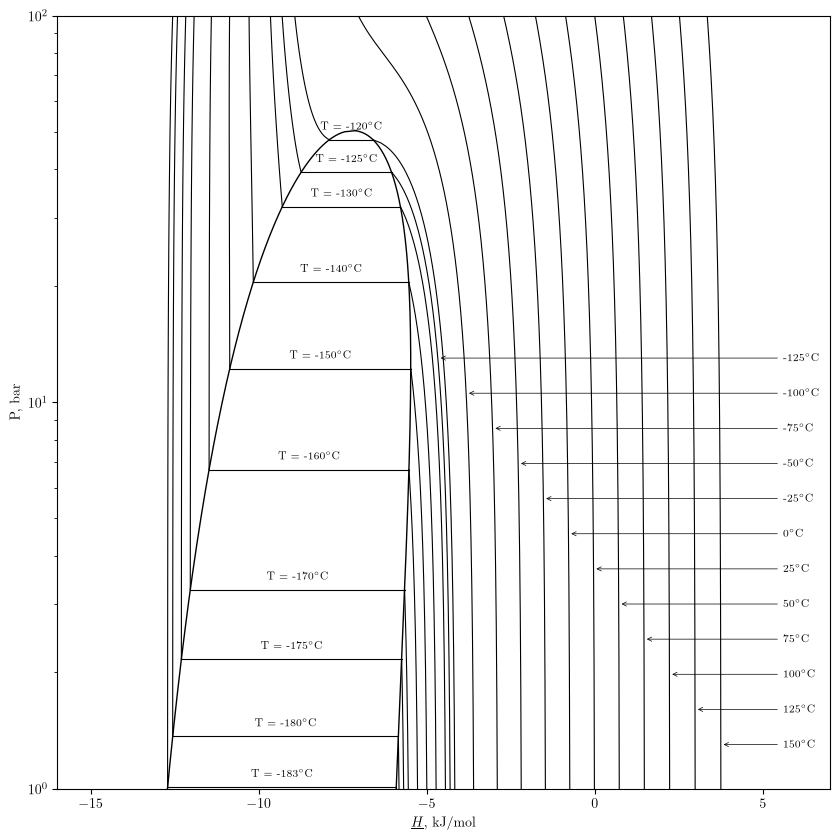

In [4]:
import os

fig, ax = plt.subplots(figsize=(8.5, 8.5))
BLACK = "black"

supercrit = [-100, -75, -50, -25, 0, 25, 50, 75, 100, 125, 150]
subcrit = [-120, -125, -130, -140, -150, -160, -170, -175, -180, -183]


def H_kJ(P, T, phase):
    return enthalpy(P, T, phase) / KJ


for TC in supercrit:
    T = TC + TO_KELVIN
    P = np.logspace(0, 2, 400) * BAR
    ax.plot([H_kJ(p, T, "vapor") for p in P], P / BAR, "-", color=BLACK, lw=0.8)

for TC in subcrit:
    T = TC + TO_KELVIN
    ps = Psat(T)
    if ps is None:
        continue
    Pv = np.logspace(0, np.log10(ps / BAR), 200) * BAR
    ax.plot([H_kJ(p, T, "vapor") for p in Pv], Pv / BAR, "-", color=BLACK, lw=0.8)
    Pl = np.logspace(np.log10(ps / BAR), 2, 120) * BAR
    ax.plot([H_kJ(p, T, "liquid") for p in Pl], Pl / BAR, "-", color=BLACK, lw=0.8)
    ax.plot([H_kJ(ps, T, "vapor"), H_kJ(ps, T, "liquid")], [ps / BAR, ps / BAR],
            "-", color=BLACK, lw=0.8)
    Hmid = 0.5 * (H_kJ(ps, T, "vapor") + H_kJ(ps, T, "liquid"))
    ax.text(Hmid, ps / BAR * 1.05, f"T = {TC}$^\\circ$C", fontsize=7.5,
            ha="center", va="bottom")

ax.plot(envelope.HL / KJ, envelope.P / BAR, "-", color=BLACK, lw=1)
ax.plot(envelope.HV / KJ, envelope.P / BAR, "-", color=BLACK, lw=1)

key_T = [-125, -100, -75, -50, -25, 0, 25, 50, 75, 100, 125, 150]
P_key = np.logspace(np.log10(13), np.log10(1.3), len(key_T))
for TC, P_lab in zip(key_T, P_key):
    T = TC + TO_KELVIN
    H_head = H_kJ(P_lab * BAR, T, "vapor")
    ax.annotate(f"{TC}$^\\circ$C",
                xy=(H_head, P_lab), xycoords="data",
                xytext=(5.6, P_lab), textcoords="data",
                fontsize=7.5, va="center", ha="left",
                arrowprops=dict(arrowstyle="->", lw=0.5, color=BLACK))

ax.set_yscale("log")
ax.set_xlim(-16, 7)
ax.set_ylim(1, 100)
ax.set_xlabel("$\\underline{H}$, kJ/mol")
ax.set_ylabel("P, bar")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-4_thermo.pdf", dpi=300, bbox_inches="tight")
plt.show()
